市场情绪因子 M 已成功导出到 C:\Users\wrz\Desktop\FYPProject\market_sentiment_factor.csv


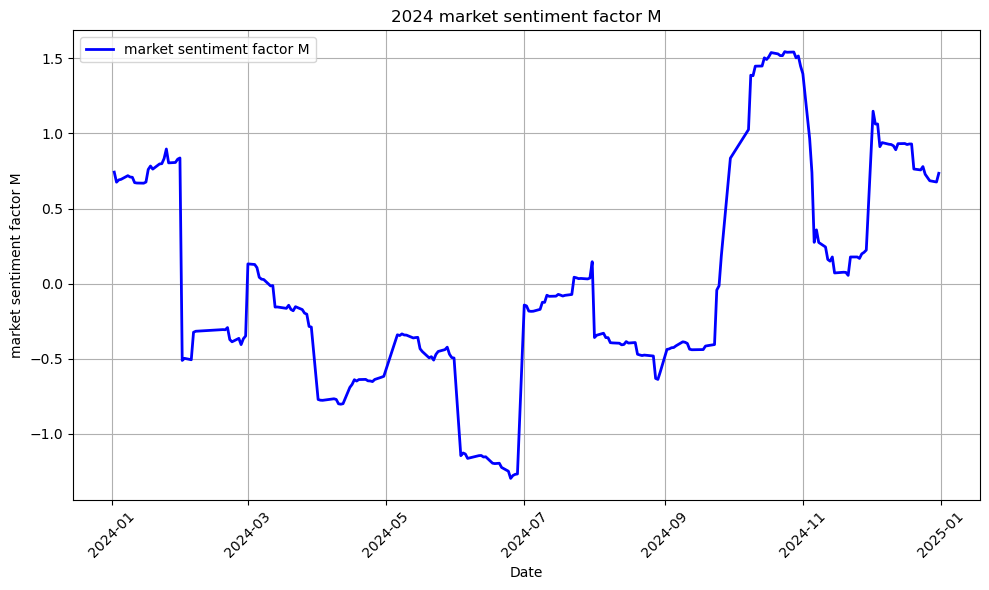

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_csi300 = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\000300.SH.csv', parse_dates=['日期'])
df_csi300 = df_csi300.sort_values('日期')
df_csi300['return'] = df_csi300['收盘价(元)'].pct_change()


df_csi300['volatility'] = df_csi300['return'].rolling(window=20).std()


df_epu = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\China_EPU.csv')  # 包含 year, month, EPU
df_epu['date'] = pd.to_datetime(df_epu[['year', 'month']].assign(day=1))

df_epu_daily = pd.DataFrame({'日期': df_csi300['日期'].unique()})
df_epu_daily['year'] = df_epu_daily['日期'].dt.year
df_epu_daily['month'] = df_epu_daily['日期'].dt.month
df_epu_daily = df_epu_daily.merge(df_epu[['year', 'month', 'EPU']], on=['year', 'month'], how='left')


df_m = df_csi300[['日期', 'volatility']].merge(df_epu_daily[['日期', 'EPU']], on='日期', how='left')
df_m = df_m[(df_m['日期'] >= '2024-01-01') & (df_m['日期'] <= '2024-12-31')]


df_m['vol_norm'] = (df_m['volatility'] - df_m['volatility'].mean()) / df_m['volatility'].std()
df_m['epu_norm'] = (df_m['EPU'] - df_m['EPU'].mean()) / df_m['EPU'].std()


df_m['M'] = 0.5 * df_m['vol_norm'] + 0.5 * df_m['epu_norm']


output_path = r'C:\Users\wrz\Desktop\FYPProject\market_sentiment_factor.csv'
df_m[['日期', 'M']].to_csv(output_path, index=False)

print(f"M 已导出到 {output_path}")


plt.figure(figsize=(10, 6))
plt.plot(df_m['日期'], df_m['M'], label='market sentiment factor M', color='b', linewidth=2)
plt.title('2024 market sentiment factor M')
plt.xlabel('Date')
plt.ylabel('market sentiment factor M')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

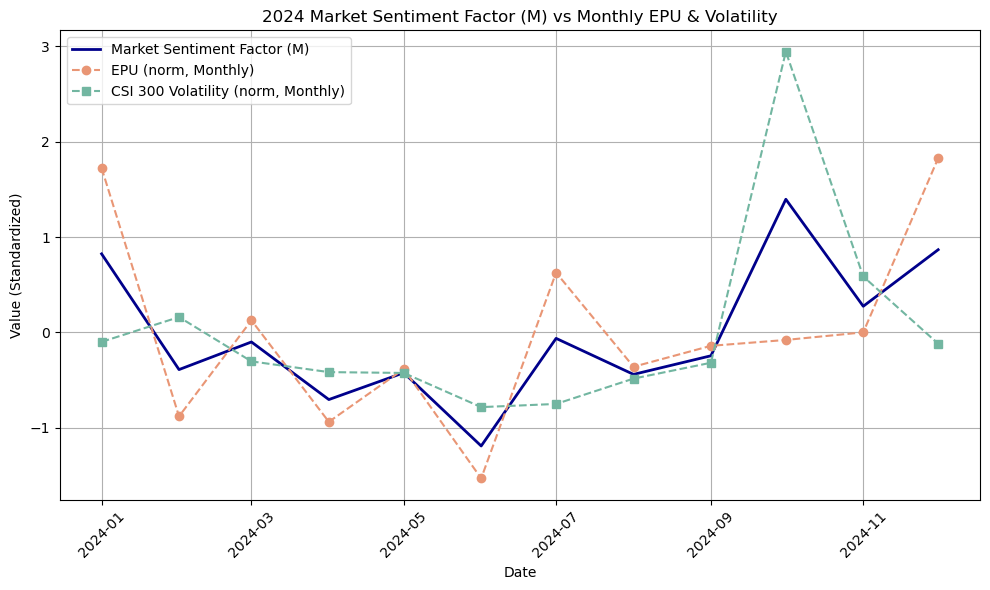

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


FREQ = 'M'  


df_csi300 = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\000300.SH.csv', parse_dates=['日期'])
df_csi300 = df_csi300.sort_values('日期')
df_csi300['return'] = df_csi300['收盘价(元)'].pct_change()
df_csi300['volatility'] = df_csi300['return'].rolling(window=20).std()


df_epu = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\China_EPU.csv')
df_epu['date'] = pd.to_datetime(df_epu[['year', 'month']].assign(day=1))


df_epu_daily = pd.DataFrame({'日期': df_csi300['日期'].unique()})
df_epu_daily['year'] = df_epu_daily['日期'].dt.year
df_epu_daily['month'] = df_epu_daily['日期'].dt.month
df_epu_daily = df_epu_daily.merge(df_epu[['year', 'month', 'EPU']], on=['year', 'month'], how='left')


df_m = df_csi300[['日期', 'volatility']].merge(df_epu_daily[['日期', 'EPU']], on='日期', how='left')
df_m = df_m[(df_m['日期'] >= '2024-01-01') & (df_m['日期'] <= '2024-12-31')]


df_m['vol_norm'] = (df_m['volatility'] - df_m['volatility'].mean()) / df_m['volatility'].std()
df_m['epu_norm'] = (df_m['EPU'] - df_m['EPU'].mean()) / df_m['EPU'].std()
df_m['M_daily'] = 0.5 * df_m['vol_norm'] + 0.5 * df_m['epu_norm']


def assign_period(date):
    if FREQ == '2W':
        return pd.Timestamp(year=date.year, month=date.month, day=1 if date.day <= 15 else 16)
    elif FREQ == 'W':
        return date - pd.Timedelta(days=date.weekday()) 
    elif FREQ == 'D':
        return date
    else:  
        return pd.Timestamp(year=date.year, month=date.month, day=1)

df_m['period'] = df_m['日期'].apply(assign_period)

df_grouped = df_m.groupby('period')['M_daily'].mean().reset_index()
df_grouped.rename(columns={'M_daily': 'M'}, inplace=True)


output_path = fr'C:\Users\wrz\Desktop\FYPProject\market_sentiment_factor_{FREQ}.csv'
df_grouped.to_csv(output_path, index=False)
print(f"M（{FREQ}）已导出到：{output_path}")


plt.figure(figsize=(10, 6))

plt.plot(df_grouped['period'], df_grouped['M'], label=f'Market Sentiment Factor ({FREQ})', color='darkblue', linewidth=2)

df_epu['date'] = pd.to_datetime(df_epu[['year', 'month']].assign(day=1))
df_csi300['month'] = df_csi300['日期'].dt.to_period('M')
monthly_vol = df_csi300.groupby('month')['volatility'].mean().reset_index()
monthly_vol['month'] = monthly_vol['month'].dt.to_timestamp()


df_epu_2024 = df_epu[(df_epu['date'] >= '2024-01-01') & (df_epu['date'] <= '2024-12-31')]
monthly_vol_2024 = monthly_vol[(monthly_vol['month'] >= '2024-01-01') & (monthly_vol['month'] <= '2024-12-31')]


df_overlay = pd.merge(monthly_vol_2024, df_epu_2024[['date', 'EPU']], left_on='month', right_on='date')
df_overlay['EPU_norm'] = (df_overlay['EPU'] - df_overlay['EPU'].mean()) / df_overlay['EPU'].std()
df_overlay['vol_norm'] = (df_overlay['volatility'] - df_overlay['volatility'].mean()) / df_overlay['volatility'].std()


plt.plot(df_overlay['month'], df_overlay['EPU_norm'], label='EPU (norm, Monthly)', color='#e99675', linestyle='--', marker='o')
plt.plot(df_overlay['month'], df_overlay['vol_norm'], label='CSI 300 Volatility (norm, Monthly)', color='#72b6a1', linestyle='--', marker='s')

plt.title(f'2024 Market Sentiment Factor ({FREQ}) vs Monthly EPU & Volatility')
plt.xlabel('Date')
plt.ylabel('Value (Standardized)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


